# Exploratory Data Analysis (EDA)
## Late Delivery Risk Scoring in Global Supply Chains
---
### Goal:
*  understand the story in the cleaned dataset before modeling
*  answer four questions:
   1. what does each key variable look like?
   2. how do variables relate to each other?
   3. what patterns connect to late delivery?
   4. what issues might affect modeling?

### Expected Output:
 - distribution plots for numerical and categorical columns
 - relationship plots between features and the target
 - correlation view for numerical features
 - written insights under each plot

### This EDA feeds directly into:
- which features to use for clustering
- strongest predictors for the classifier
- features most correlated with delay_gap
- how profit and delay interact for the risk score
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# load the cleaned dataset saved by the team
df = pd.read_csv('dataco_cleaned.csv', encoding='latin1')

print(df.shape)
print(df.columns.tolist())

(180519, 46)
['transaction_type', 'shipping_days_actual', 'shipping_days_scheduled', 'profit_per_order', 'customer_total_sales', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'store_latitude', 'store_longitude', 'market', 'order_city', 'order_country', 'order_date', 'order_id', 'item_discount_amount', 'item_discount_rate', 'order_item_id', 'item_profit_ratio', 'item_quantity', 'item_sales', 'item_total', 'order_region', 'order_state', 'order_status', 'product_id', 'product_name', 'product_price', 'shipping_date', 'shipping_mode', 'profit_ratio_extreme_loss', 'order_year', 'order_month', 'order_weekday', 'order_quarter', 'delay_gap']


---
## What does each key variable look like?

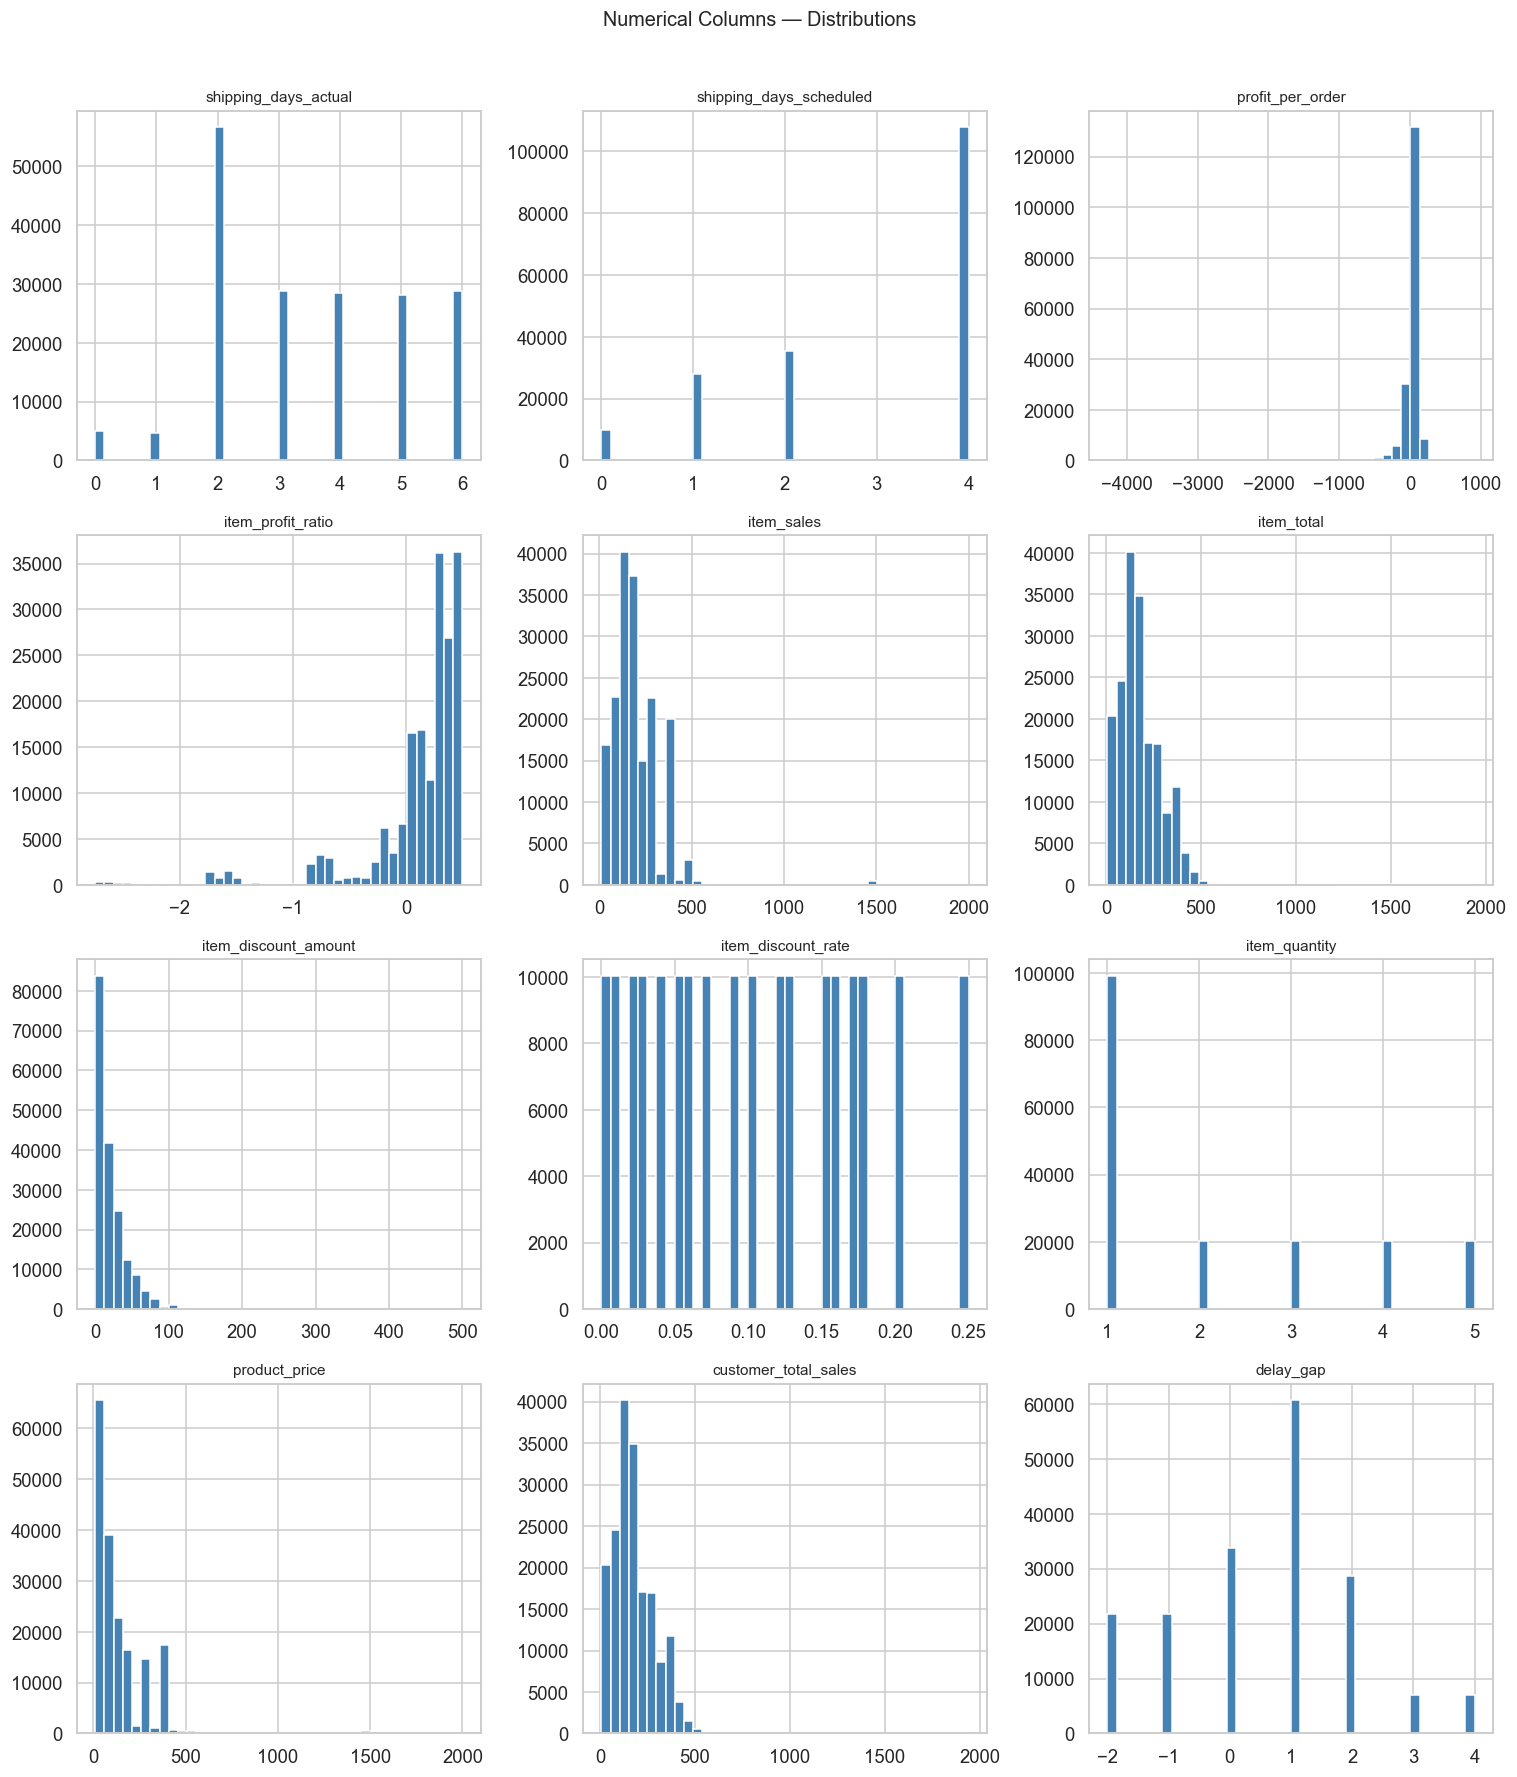

In [2]:
# ===========================================
# starting with numerical columns
# excluding IDs since they carry no analytical value
# ===========================================

cols_to_plot = [
    'shipping_days_actual', 'shipping_days_scheduled',
    'profit_per_order', 'item_profit_ratio',
    'item_sales', 'item_total',
    'item_discount_amount', 'item_discount_rate',
    'item_quantity', 'product_price',
    'customer_total_sales', 'delay_gap'
]

fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Numerical Columns — Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Distribution Insights (Visual Summary)

- **Shipping Time**
  - Actual shipping is spread between 2–6 days, with a peak at 2
  - Scheduled shipping is mostly fixed at 4 days  
  - → Explains why most delays are +1 day (actual 5 vs scheduled 4)

- **Profit per Order**
  - Highly concentrated near 0
  - Extreme negative outliers (~ -4000) are rare  
  - → Most orders are low-profit, with occasional large losses

- **Item Profit Ratio**
  - Bimodal distribution (peaks around -0.8 and +0.3/+0.5)  
  - → Two order types: loss-making vs profitable

- **Sales & Pricing**
  - (`item_sales`, `item_total`, `customer_total_sales`, `product_price`) are right-skewed  
  - → Log transformation recommended before modeling

- **Discounts**
  - Discount amount is heavily right-skewed (most near 0)
  - Discount rate appears in fixed bands (0–25%)  
  - → Treat as categorical feature

- **Quantity**
  - Discrete values (1–5), heavily skewed toward 1  
  - → Treat as ordinal feature

- **Delivery Delay (delay_gap)**
  - Strong peak at +1 day delay
  - Early deliveries at -1 and -2 are also common  
  - → Most delays are exactly 1 day (important modeling signal)

---

In [6]:
# ===========================================
# Categorical Distributions
# want to see unique values and how they're distributed
# ===========================================

cat_cols = [
    'shipping_mode', 'market', 'order_region',
    'customer_segment', 'transaction_type',
    'order_status', 'department_name', 'delivery_status'
]

for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    print(df[col].value_counts())
    print()

shipping_mode: 4 unique values
shipping_mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

market: 5 unique values
market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

order_region: 23 unique values
order_region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

customer_segme

## Categorical Insights

- **Shipping Mode**
  - 4 types, with *Standard Class* ≈60% of orders  
  - → Likely a key predictor (may be linked to higher delays)

- **Market**
  - 5 regions, LATAM and Europe ≈29% each  
  - → Geography likely impacts delivery performance

- **Order Region**
  - 23 regions, top: Central America & Western Europe  
  - → High cardinality → consider grouping before modeling

- **Customer Segment**
  - 3 segments  
  - → Worth testing impact on delays

- **Transaction Type**
  - 4 types, DEBIT likely dominant  
  - → Could influence order behavior

- **Order Status**
  - Multiple values (COMPLETE, PENDING, CANCELED…)  
  - → ⚠️ Risk of data leakage — use carefully

- **Delivery Status**
  - 4 values, including "Shipping canceled" (~7,754 orders)  
  - → Decide: include or exclude from delay analysis  
  - → Directly linked to late delivery → must NOT be used as a feature

---



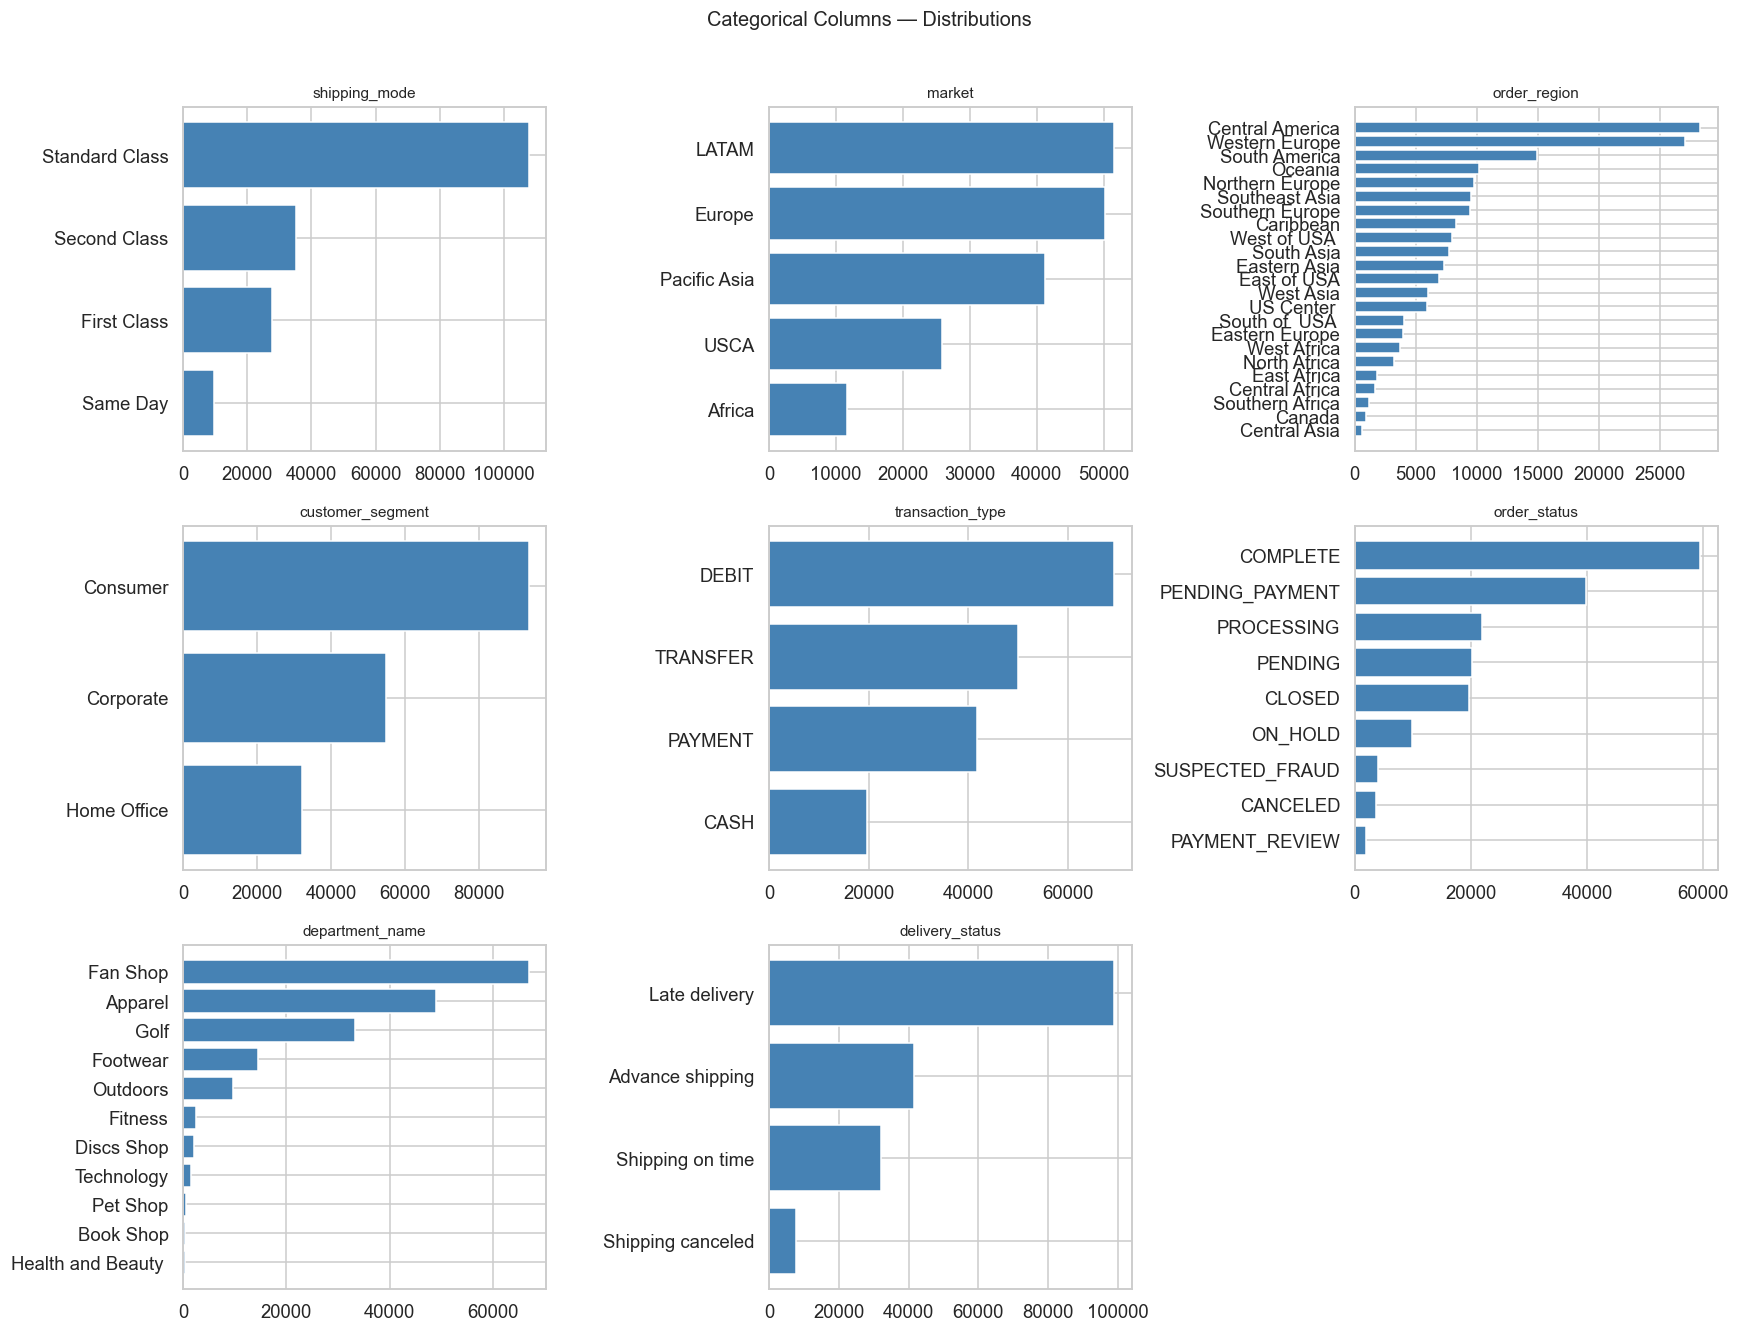

In [7]:
# ===========================================
# Visualizing Categorical Features
# ===========================================

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].invert_yaxis()

# hide the extra subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Columns — Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Categorical Distribution Insights

- **Shipping Mode**
  - Standard Class dominates (~60%)  
  - → Likely strongest predictor of late delivery  
  - Same Day is rare (~5%) → limited learning signal

- **Market**
  - LATAM & Europe lead (~29% each)  
  - Africa is underrepresented

- **Order Region**
  - 23 regions, highly imbalanced  
  - Central America & Western Europe dominate  
  - Some regions have very low volume  
  - → High cardinality → needs grouping

- **Customer Segment**
  - Consumer (~50%) > Corporate  
  - → Balanced, no cardinality issue

- **Transaction Type**
  - DEBIT dominates, CASH is least common  
  - → Likely weak predictor but worth testing

- **Order Status**
  - COMPLETE dominates  
  - CANCELED & SUSPECTED_FRAUD present  
  - → Decide whether to include canceled orders

- **Department Name**
  - Fan Shop & Apparel dominate  
  - Smaller departments have very low representation

- **Delivery Status**
  - Late delivery is highest (~55%)  
  - → Confirms class imbalance in target  
  - ⚠️ Must be excluded (direct leakage source)

---

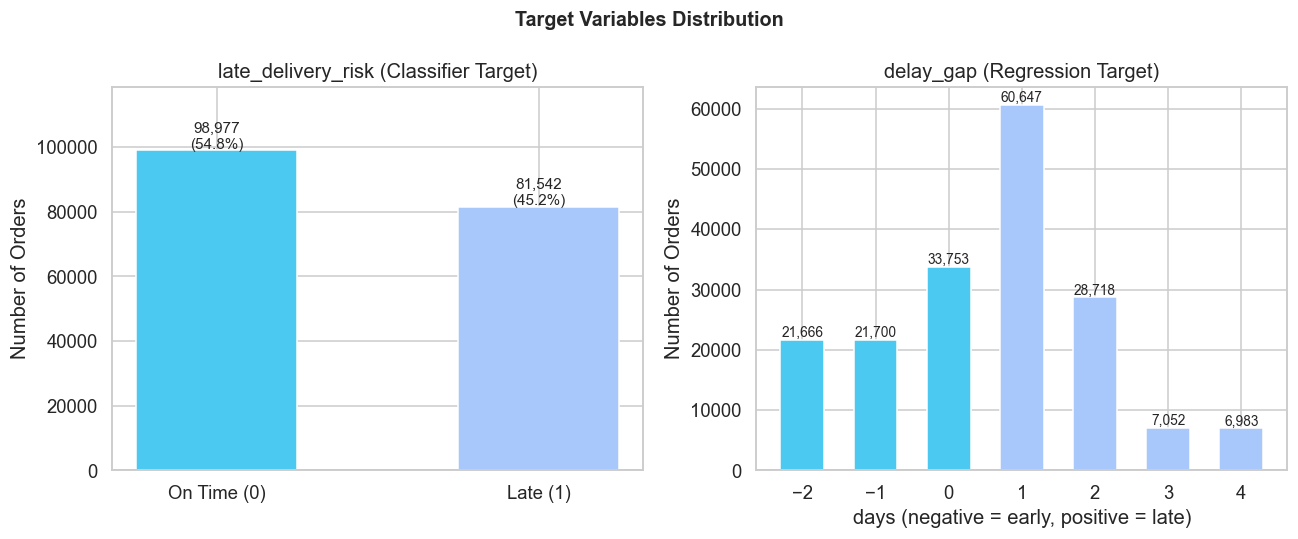

In [24]:
# ============================================================
# Target Variables Distribution
# ------------------------------------------------------------
# Visualize both targets:
# 1. late_delivery_risk → binary classifier target
# 2. delay_gap → regression target (days early/late)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── left: late_delivery_risk ─────────────────────────────
counts = df['late_delivery_risk'].value_counts()
bars = axes[0].bar(['On Time (0)', 'Late (1)'],
                   counts.values,
                   color=['#4CC9F0', '#A8C7FA'],
                   width=0.5)

for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

axes[0].set_title('late_delivery_risk (Classifier Target)')
axes[0].set_ylabel('Number of Orders')
axes[0].set_ylim(0, counts.max() * 1.2)

# ── right: delay_gap ─────────────────────────────────────
gap_counts = df['delay_gap'].value_counts().sort_index()
colors = ['#4CC9F0' if x <= 0 else '#A8C7FA' for x in gap_counts.index]

axes[1].bar(gap_counts.index, gap_counts.values, color=colors, width=0.6)
axes[1].set_title('delay_gap (Regression Target)')
axes[1].set_xlabel('days (negative = early, positive = late)')
axes[1].set_ylabel('Number of Orders')

for val, cnt in zip(gap_counts.index, gap_counts.values):
    axes[1].text(val, cnt + 500, f'{cnt:,}',
                 ha='center', fontsize=9)

plt.suptitle('Target Variables Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## How do variables relate to each other?


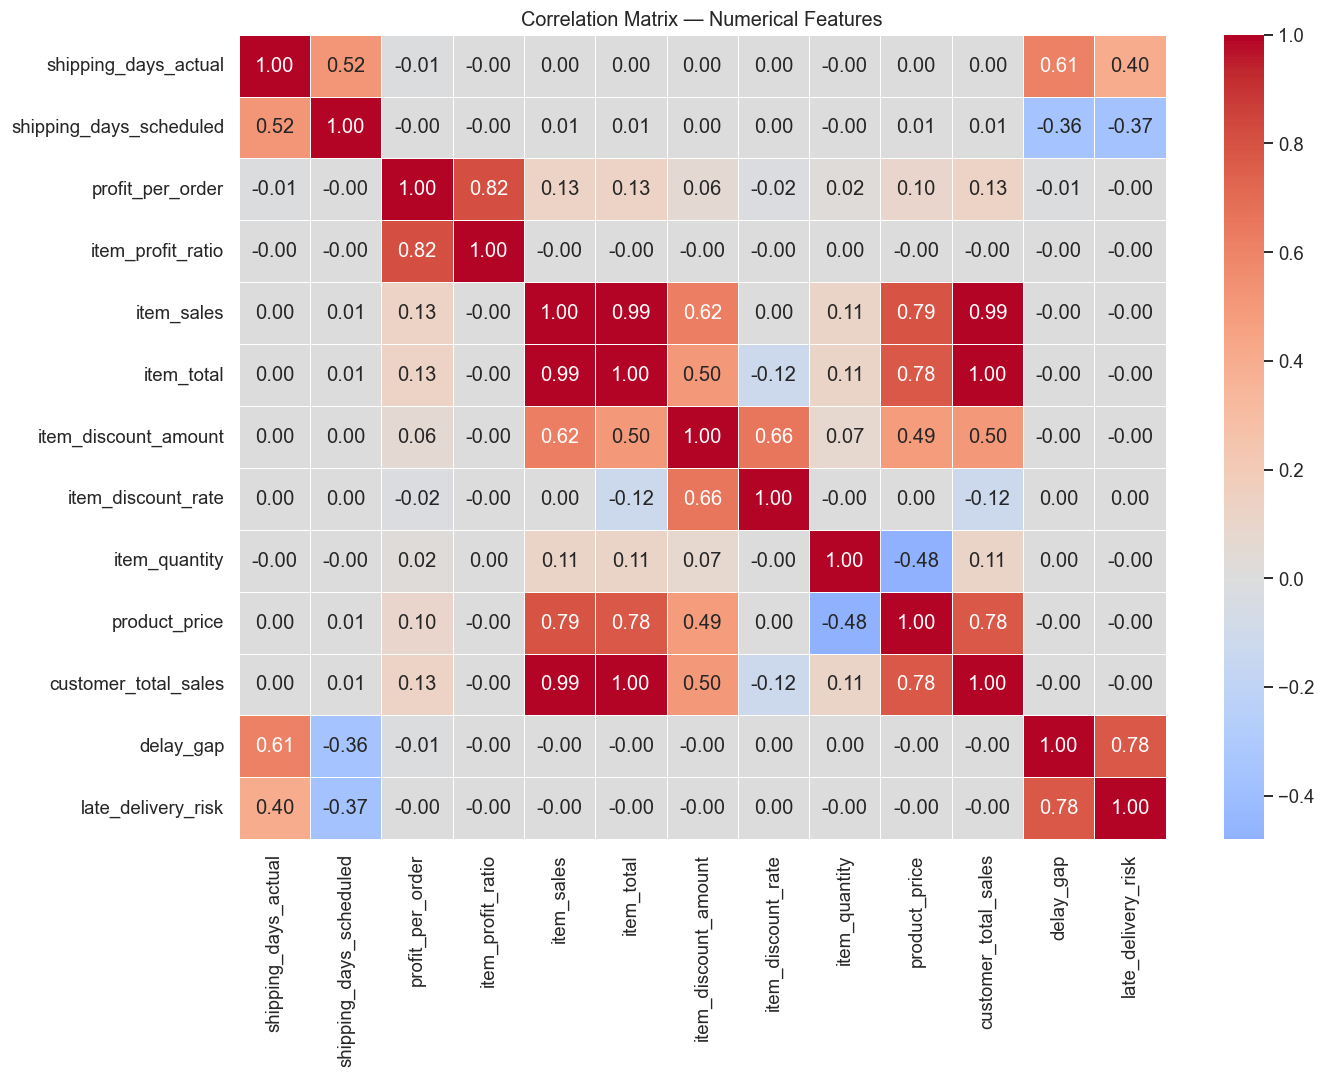

In [9]:
# ===========================================
# Correlation Heatmap (Numerical Features)
# Helps identify:
# - Features strongly correlated with **late_delivery_risk** or **delay_gap**
# - Features correlated with each other → potential **multicollinearity** issues
# ===========================================

num_cols = [
    'shipping_days_actual', 'shipping_days_scheduled',
    'profit_per_order', 'item_profit_ratio',
    'item_sales', 'item_total',
    'item_discount_amount', 'item_discount_rate',
    'item_quantity', 'product_price',
    'customer_total_sales', 'delay_gap',
    'late_delivery_risk'
]

corr = df[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)

ax.set_title('Correlation Matrix — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()

## Correlation Insights

### Strong Correlations with Target
- **delay_gap vs late_delivery_risk:** 0.78 → expected, measures same concept  
- **shipping_days_actual vs delay_gap:** 0.61 → longer actual shipping → higher delay  
- **shipping_days_scheduled vs delay_gap:** -0.36 → longer scheduled shipping → lower delay risk  
- **shipping_days_actual vs late_delivery_risk:** 0.40  
- **shipping_days_scheduled vs late_delivery_risk:** -0.37  
- → **Shipping days** are key numerical predictors

### Multicollinearity Issues
- **item_sales vs item_total:** 0.99 → almost identical  
- **item_sales vs customer_total_sales:** 0.99 → redundant  
- **item_total vs customer_total_sales:** 1.00 → exact duplicate  
- **product_price vs item_sales:** 0.79  
- **profit_per_order vs item_profit_ratio:** 0.82  
- **item_discount_amount vs item_discount_rate:** 0.66

### Financial Features vs Target
- **profit_per_order, item_sales, item_total:** ~0 correlation with delay  
- → Not predictive of late delivery directly  
- → Still important for Stage 4 Risk Score (profit weighting)

### Modeling Implications
- Drop **item_total** & **customer_total_sales** (redundant)  
- Keep **shipping_days_actual** & **shipping_days_scheduled** as main numerical predictors  
- Financial features useful for Risk Score, not delay classification
---

## What patterns relate to the target?

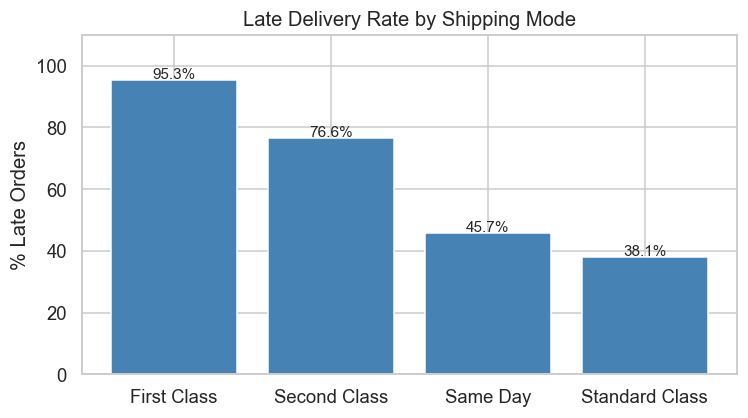

In [10]:
# ===========================================
# Late Delivery Rates by Shipping Mode
# ===========================================

late_by_mode = df.groupby('shipping_mode')['late_delivery_risk'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(late_by_mode.index, late_by_mode.values * 100, color='steelblue')

for bar, val in zip(bars, late_by_mode.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', fontsize=10)

ax.set_title('Late Delivery Rate by Shipping Mode')
ax.set_ylabel('% Late Orders')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

## Shipping Mode vs Late Delivery Risk

- **Observed Late Rates:**
  - First Class: 95.3% → almost always late  
  - Second Class: 76.6%  
  - Same Day: 45.7%  
  - Standard Class: 38.1% → most reliable

- **Counter-Intuitive Insight:**
  - First Class expected to be fastest, but often late
  - Likely due to **shorter scheduled windows** being harder to meet

- **Key Takeaway:**
  - **delay_gap** captures lateness more accurately than binary late/not
  - Scheduled window length is crucial:
    - First Class: 1–2 days → higher chance of delay  
    - Standard Class: 4 days → more buffer, arrives on time

- **Modeling Implication:**
  - Shipping mode is likely the strongest predictor  
  - Consider interaction with **shipping_days_scheduled**

In [12]:
# Number of scheduled shipping days for each Shipping_mode
scheduled_by_mode = df.groupby('shipping_mode')['shipping_days_scheduled'].describe()
print(scheduled_by_mode)

                   count  mean  std  min  25%  50%  75%  max
shipping_mode                                               
First Class      27814.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0
Same Day          9737.0   0.0  0.0  0.0  0.0  0.0  0.0  0.0
Second Class     35216.0   2.0  0.0  2.0  2.0  2.0  2.0  2.0
Standard Class  107752.0   4.0  0.0  4.0  4.0  4.0  4.0  4.0



- **Fixed Scheduled Days per Mode:**
  - Same Day → 0 days  
  - First Class → 1 day  
  - Second Class → 2 days  
  - Standard Class → 4 days

- **Impact on Late Delivery:**
  - **First Class:** 95.3% late  
    - Promises 1 day, actual delivery 2–6 days → almost always late
  - **Standard Class:** 38.1% late  
    - Promises 4 days, actual delivery 2–4 days → easier to meet

- **Key Insight:**
  - **late_delivery_risk** depends on **gap between scheduled and actual**, not just actual days  
  - Shipping mode indirectly encodes this gap  
  - → Likely the **strongest feature**
---

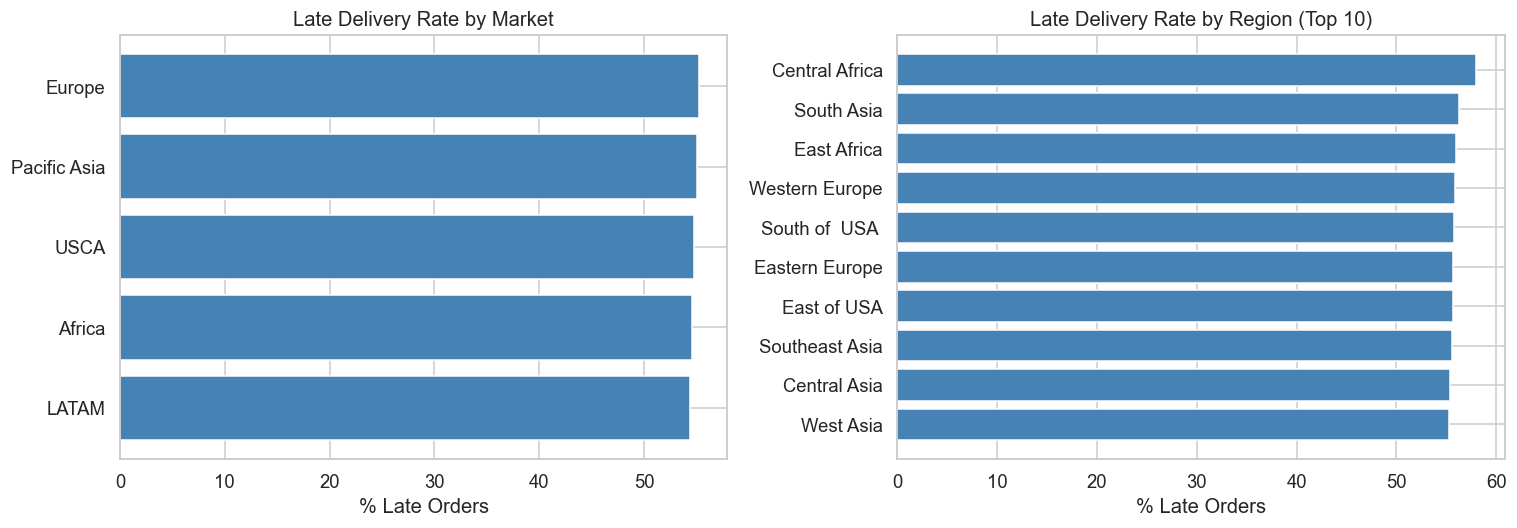

In [13]:
# ===========================================
#  Late Delivery Rates by Market and Top Regions
# ===========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

late_by_market = df.groupby('market')['late_delivery_risk'].mean().sort_values(ascending=False)
axes[0].barh(late_by_market.index, late_by_market.values * 100, color='steelblue')
axes[0].set_title('Late Delivery Rate by Market')
axes[0].set_xlabel('% Late Orders')
axes[0].invert_yaxis()

late_by_region = df.groupby('order_region')['late_delivery_risk'].mean().sort_values(ascending=False).head(10)
axes[1].barh(late_by_region.index, late_by_region.values * 100, color='steelblue')
axes[1].set_title('Late Delivery Rate by Region (Top 10)')
axes[1].set_xlabel('% Late Orders')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Market & Region vs Late Delivery Risk

- **Market**
  - All 5 markets show similar late rates (~53–55%)  
  - → Almost no predictive power for late delivery

- **Order Region (Top 10)**
  - Late rates between 55–58%  
  - → High cardinality but minimal signal

- **Reason**
  - Late delivery is primarily driven by **shipping_mode** (scheduled vs actual days)  
  - Geography has little effect — shipping modes are applied consistently

- **Modeling Implications**
  - Market & order_region are weak Stage predictors  
  - Could still help for clustering 
  - Consider dropping both before classifier Stage

---

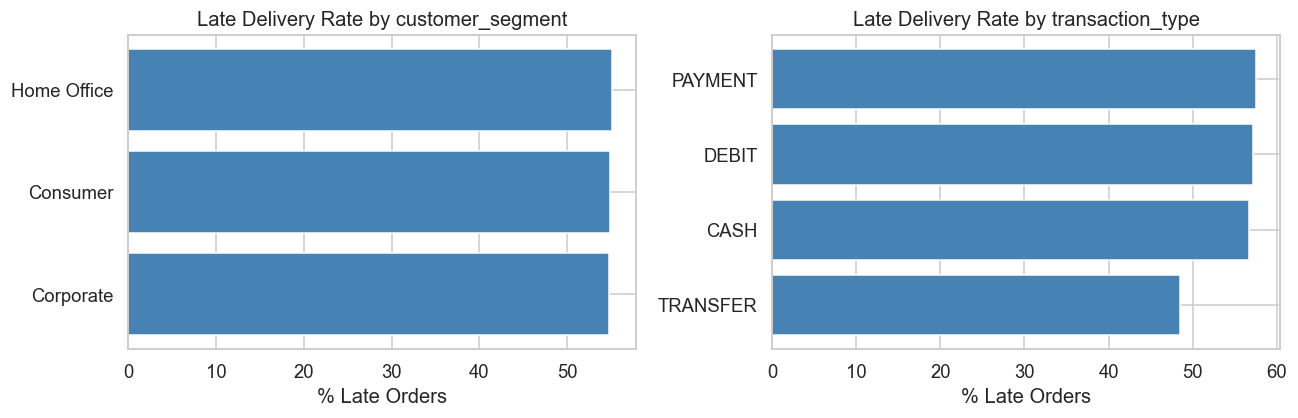

In [14]:
# ===========================================
# Customer Segment & Transaction Type vs Late Delivery Risk
# ===========================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['customer_segment', 'transaction_type']):
    late_rate = df.groupby(col)['late_delivery_risk'].mean().sort_values(ascending=False)
    ax.barh(late_rate.index, late_rate.values * 100, color='steelblue')
    ax.set_title(f'Late Delivery Rate by {col}')
    ax.set_xlabel('% Late Orders')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Customer Segment & Transaction Type vs Late Delivery Risk

- **Customer Segment**
  - All segments (~54–55% late) → Consumer, Corporate, Home Office  
  - → No meaningful difference → zero predictive power  
  - → Drop from features for predicting late delivery

- **Transaction Type**
  - PAYMENT, DEBIT, CASH: ~57–58% late  
  - TRANSFER: slightly lower (~49%)  
  - → Very weak signal → probably not worth keeping

- **Pattern**
  - Most categorical features (market, region, segment, transaction_type) show similar late rates (~54–58%)  
  - **Only shipping_mode has strong signal**

- **Modeling Implication**
  - Keep **shipping_mode** as key predictor of late delivery  
  - Consider dropping market, order_region, customer_segment, transaction_type from the model
  ---

## What issues might affect modeling?


### Modeling Considerations: Key Issues to Watch
 Objective
Identify potential challenges before building a predictive model for **late delivery**:
- Class imbalance  
- Redundant or highly correlated columns  
- Data leakage risks


In [15]:
# ===========================================
# class imbalance
# ===========================================

print('Class balance:')
print(df['late_delivery_risk'].value_counts())
print(f'ratio: {df["late_delivery_risk"].mean():.2f}')
print()

Class balance:
late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64
ratio: 0.55



In [19]:
late_ratio = df['late_delivery_risk'].value_counts(normalize=True) * 100
print(late_ratio)

late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


### late_delivery_risk
* 1 :   54.83%  — late
* 0 :   45.17%  — on time

 * difference is only ~10% — mild imbalance
 * no need for aggressive resampling (SMOTE etc.)
 * class_weight='balanced' in the model is enough Class Imbalance

In [17]:
# ===========================================
# duplicate/redundant columns
# ===========================================

print('Potentially redundant columns:')
print('item_sales vs item_total:', df['item_sales'].corr(df['item_total']).round(3))
print('item_sales vs customer_total_sales:', df['item_sales'].corr(df['customer_total_sales']).round(3))
print('profit_per_order vs item_profit_ratio:', df['profit_per_order'].corr(df['item_profit_ratio']).round(3))
print()

Potentially redundant columns:
item_sales vs item_total: 0.99
item_sales vs customer_total_sales: 0.99
profit_per_order vs item_profit_ratio: 0.824



### Redundant Columns

- **item_sales vs item_total:** correlation = 0.99  
  → Almost identical → **keep `item_sales`, drop `item_total`**

- **item_sales vs customer_total_sales:** correlation = 0.99  
  → Redundant → **drop `customer_total_sales`**

- **profit_per_order vs item_profit_ratio:** correlation = 0.82  
  → Highly correlated but not identical  
  → `profit_per_order` is in dollars (business meaningful)  
  → `item_profit_ratio` is a percentage  
  → **Keep `profit_per_order` for Risk Score calculation, drop `item_profit_ratio`**

- **Summary:** Dropping these columns reduces noise without losing predictive signal  
- Actual column removal will occur during **feature engineering** before modeling

In [18]:
# ===========================================
# leakage risk columns
# ===========================================

print('Columns to EXCLUDE from features (leakage risk):')
leakage_cols = ['delivery_status', 'shipping_days_actual', 'shipping_date', 'delay_gap']
for col in leakage_cols:
    print(f'  {col}')

Columns to EXCLUDE from features (leakage risk):
  delivery_status
  shipping_days_actual
  shipping_date
  delay_gap


## Leakage Risk: Columns to Exclude from Classifier Features

- **delivery_status:** direct text version of the target → knowing it reveals the answer  
- **shipping_days_actual:** only known after delivery → not available at order time  
- **shipping_date:** only known after dispatch → future information  
- **delay_gap:** computed from `shipping_days_actual` → leakage and used as regression target  

### Notes on Features
- **shipping_days_scheduled:**  
  - Known at order time → safe to keep  
  - Perfectly correlated with `shipping_mode` → drop one of the two before modeling

### Rule of Thumb
> Any column **only known after the event we are predicting** is a **leakage risk** → exclude from features

---
# EDA Summary & Next Steps

## 1. Target Insights
- **Class balance:** 54.8% late vs 45.2% on time → mild imbalance
- Most delays are **exactly 1 day** (`delay_gap` spikes at +1)
- `delay_gap` range: -2 to +4 days

## 2. Strongest Predictor
- **Shipping Mode dominates:**
  - First Class → 95.3% late  
  - Second Class → 76.6% late  
  - Same Day → 45.7% late  
  - Standard Class → 38.1% late
- Reason: fixed scheduled windows
  - First Class promises 1 day but takes 2–6 → almost always late
  - Standard Class promises 4 days → easier to meet

## 3. Weak Predictors
- Market, order_region, customer_segment, transaction_type  
  → all ~54–57% late → no meaningful signal  
  → late delivery driven by logistics, not customer or geography

## 4. Financial Features
- Near-zero correlation with `late_delivery_risk`
- Not useful for predicting delays  
- Still essential for **Risk Score** (profit weight)

## 5. Multicollinearity
- item_sales ≈ item_total ≈ customer_total_sales (r=0.99)  
- profit_per_order ≈ item_profit_ratio (r=0.82)  
- shipping_mode = shipping_days_scheduled (perfect 1:1 mapping)

## 6. Leakage Columns
- delivery_status, shipping_days_actual, shipping_date, delay_gap  
- Known **after delivery** → must never be used as features

---

# Next Steps: Preparing Data for Modeling

After completing the EDA, the next step is to **prepare the dataset for modeling**. This involves a few clear actions:

---

## 1. Feature Selection
- **Drop columns that should not be used as features:**
  - **Leakage / future information:** `delivery_status`, `shipping_days_actual`, `shipping_date`, `delay_gap`  
  - **Redundant columns:** `item_total`, `customer_total_sales`, `item_profit_ratio`, `shipping_days_scheduled` (keep only one of the last two)  
  - **Weak predictors:** `market`, `order_region`, `customer_segment`, `transaction_type`  
  - **IDs / high cardinality:** `order_id`, `order_item_id`, `customer_id`, `product_id`, `category_id`, `department_id`, `customer_street`, `customer_city`, `customer_state`, `customer_country`, `customer_zipcode`, `order_city`, `order_state`, `order_country`

- **Keep as features:**
  - Strong predictors: `shipping_mode` (encode properly)  
  - Financial features: `profit_per_order`, `item_sales`, `item_discount_amount`, `item_discount_rate`, `product_price`  
  - Order characteristics: `item_quantity`, `department_name`  
  - Temporal features: `order_year`, `order_month`, `order_weekday`, `order_quarter`  
  - Extreme loss flag: `profit_ratio_extreme_loss`

---

## 2. Feature Engineering
- **Encoding categorical features:**
  - `shipping_mode` → label or one-hot encoding  
  - `department_name` → one-hot encoding  
  - `item_discount_rate` → treat as categorical bands
- **Scaling numerical features:**
  - Needed for linear models: `profit_per_order`, `item_sales`, `product_price`, `item_discount_amount`  
  - Tree-based models (Random Forest, XGBoost) do not require scaling

---

## 3. Train/Test Split
- Standard **80/20 split**, stratified on `late_delivery_risk` to preserve class balance  
- Same split should be used for all model comparisons

---

## 4. Targets
- **Classifier:** `late_delivery_risk` (0/1)  
- **Regressor:** `delay_gap` (continuous)

---

> ✅ Once these steps are done, the dataset will be ready for modeling: building the classifier for late delivery, the regressor for delay gap, and calculating the final risk score.

| Stage               | Input              | Process                                   | Output                                 |
| ------------------- | ------------------ | ----------------------------------------- | -------------------------------------- |
| Feature Selection   | Raw dataset        | Drop leakage, redundant, weak, ID columns | Cleaned dataset with selected features |
| Feature Engineering | Cleaned dataset    | Encode categorical, scale numeric         | Ready-for-model dataset                |
| Train/Test Split    | Engineered dataset | Split 80/20, stratify on target           | X_train, X_test, y_train, y_test       |
| Modeling Targets    | Split datasets     | Select classifier or regressor target     | Prepared X/y pairs for modeling        |


---

| Stage                       | Type                      | Baseline                                   | Improved                                                                         | Hyperparameter Tuning                                                                                                              | Input                                               | Output                                              | Notes                                                                                      |
| --------------------------- | ------------------------- | ------------------------------------------ | -------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------- | --------------------------------------------------- | ------------------------------------------------------------------------------------------ |
| 1. K-Means Clustering       | Unsupervised              | K-Means (small k, scaled numeric features) | K-Means (tuned k using elbow/silhouette, optional PCA, better feature selection) | `n_clusters`, `init`, `max_iter`                                                                                                   | Engineered features only (no target)                | `cluster_id` for each row, cluster centroids        | Discover patterns in orders/customers; used for profiling, not prediction                  |
| 2. Late Delivery Classifier | Supervised Classification | Logistic Regression                        | XGBoost Classifier                                                               | Logistic Regression: `C`, `class_weight`<br>XGBoost: `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree` | Features + `late_delivery_risk` (0/1)               | Predicted probabilities (`p_late`) and labels (0/1) | Predict whether an order will be late; strongest feature: shipping_mode                    |
| 3. Delay Gap Regressor      | Supervised Regression     | Linear Regression                          | Random Forest Regressor                                                          | Random Forest: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`                                                | Features + `delay_gap` (continuous)                 | Predicted delay in days (`predicted_delay_gap`)     | Estimate how many days an order will be late; input to Risk Score                          |
| 4. Risk Score Calculation   | Deterministic / Formula   | N/A                                        | N/A                                                                              | N/A                                                                                                                                | `p_late`, `predicted_delay_gap`, `profit_per_order` | Risk Score per order (numeric)                      | Combines probability of delay, expected delay, and profit to prioritize orders financially |
